est memory spike: 3.0GB
simulation size: sim.Nx=2048, sim.Ny=2048, sim.Nz=1000
float32 (intensity) requirement: 0.24605169892311096 GB
z-resolution: 10.0μm
config file: results/rickrollQR_f5_zoom_pad2048/config.yaml


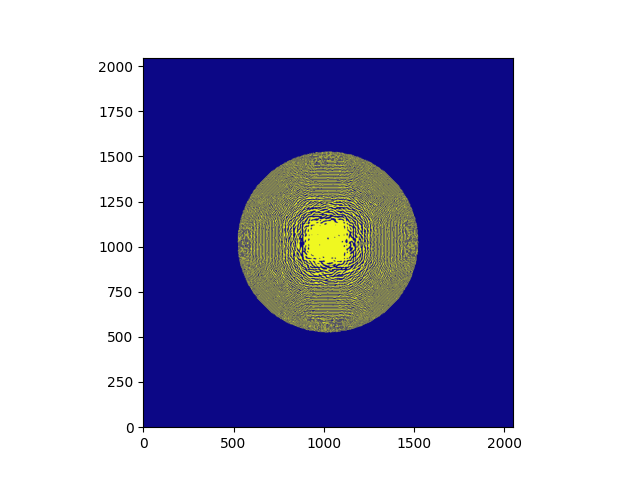

In [1]:
config_path = "results/rickrollQR_f5_zoom_pad2048/config.yaml"
import numpy as np; import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
import src.ASM as ASM
import src.math_tool as mt
import src.img_tool as it
import src.load_config as lc
%matplotlib widget
%load_ext autoreload
%autoreload 2
c, π = lc.load(config_path), np.pi
print(f'est memory spike: {c.sim.num_process * c.sim.z_batch_size * c.sim.Nx * c.sim.Ny * 2 * 128 / 8 / 1024**3}GB') # *2 cuz npfft is not in-place operation
print(f'simulation size: sim.Nx={c.sim.Nx}, sim.Ny={c.sim.Ny}, sim.Nz={c.sim.Nz}\nfloat32 (intensity) requirement: {c.Nx * c.Ny * c.Nz * 32 / 8 / 1024 / 1024 / 1024} GB\nz-resolution: {(c.sim.z_end - c.sim.z_start)/c.sim.Nz}μm\nconfig file: {config_path}')
if (np.array([c.sim.Nx, c.sim.Ny]) != np.array(c.aperture.shape)).any():
    raise Exception(f'error: loaded aperture dimension mismatch\nloaded file size: {c.aperture.shape}')
plt.imshow(c.aperture.T, cmap='plasma')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# compute and save results
ASM.ASM_3D_batch_E2_Multi_Process(c.aperture, c.sim.Lx, c.sim.Ly, c.sim.zs, c.λ, c.path.E2, c.sim.z_batch_size, c.saved_xy_range_index, num_process=c.sim.num_process)
time = datetime.now()
print(f'last run: {time.isoformat(timespec="minutes")}')

In [2]:
# extract results
E2 = ASM.batch_E2_extract(c.Nx, c.Ny, c.Nz, c.path.E2, c.sim.z_batch_size)
time = datetime.now()
print(f'last run: {time.isoformat(timespec="minutes")}')

extracting: 100%|██████████| 250/250 [00:02<00:00, 118.72it/s]

last run: 2025-11-28T19:42


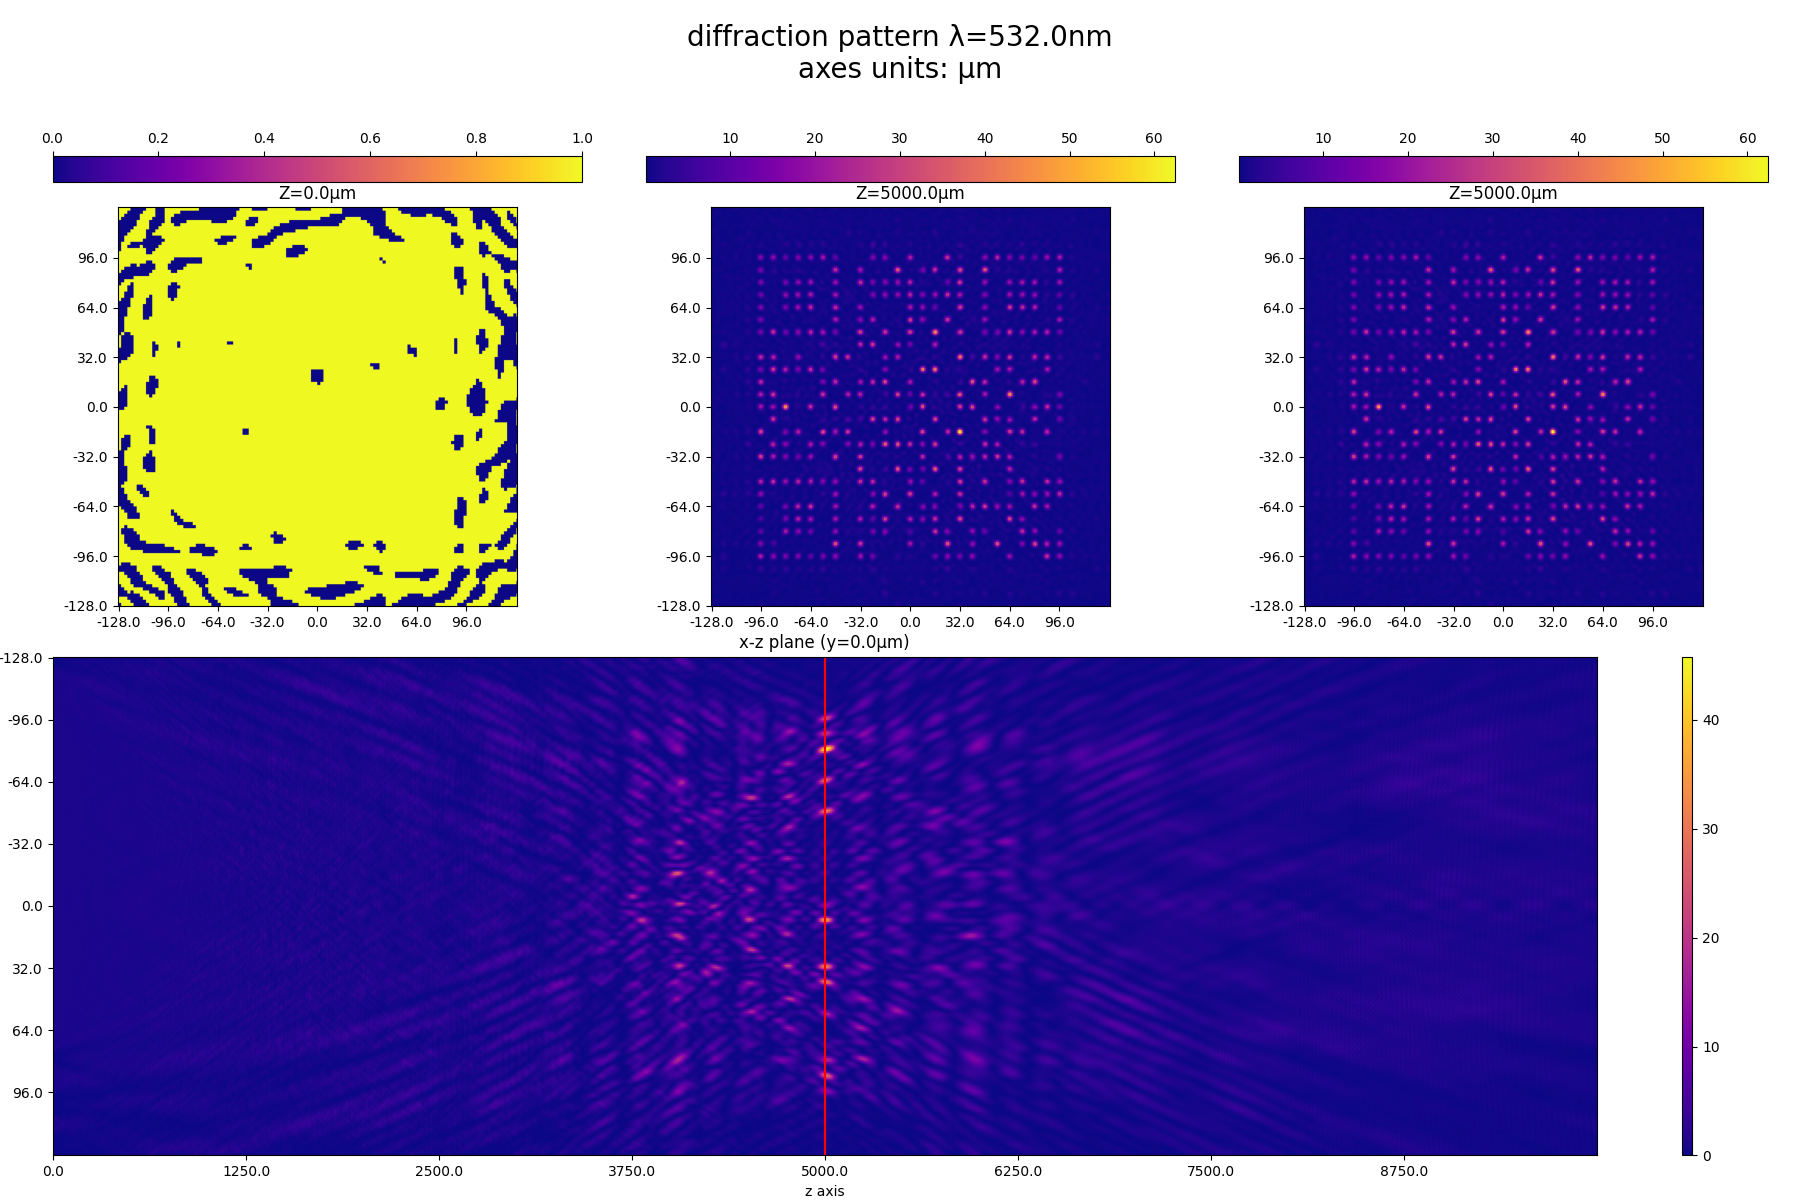

0-th to 10-th highest intensity
[62.456787 61.5882   58.814766 56.55771  51.376335 48.679707 42.371662
 38.22551  35.254868 35.026707]
at
[5000. 4990. 5010. 4980. 5020. 4970. 5030. 4960. 4520. 4510.] μm
index
[500 499 501 498 502 497 503 496 452 451]


In [3]:
# x, y plot at different zs
E2_max = E2.max(axis=(0, 1)) # Nz # find peak intensity
s = 0
order = np.flip(np.argsort(E2_max[s:])) + s
focal_z_idx = order[0]
layout = [[0, 1, 2], [3,3,3]]
plot_z_idxs = [0, 500, focal_z_idx]                                                              # <-- edit plotted z-location here
E2_plot = [E2[:, :, plot_z_idxs[0]], E2[:, :, plot_z_idxs[1]], E2[:, :, plot_z_idxs[2]]]
# plt.clf()
fig, ax = plt.subplot_mosaic(layout, figsize=(18,12))
fig.suptitle(f'diffraction pattern λ={c.λ*1e3}nm\naxes units: μm', fontsize=20)
fig.tight_layout(pad=1.5)
for i in range(len(plot_z_idxs)):
    tmp = ax[i].imshow(E2_plot[i].T, aspect='equal', cmap='plasma')
    ax[i].invert_yaxis()
    ax[i].set_xticks(c.x_tick_idxs, c.xs[c.x_tick_idxs])
    ax[i].set_yticks(c.y_tick_idxs, c.ys[c.y_tick_idxs])
    ax[i].set_title(f'Z={c.zs[plot_z_idxs[i]]}μm')
    fig.colorbar(tmp, ax=[ax[i]], location='top')
y_idx = c.Ny//2
ax[3].set_title(f'x-z plane (y={c.ys[y_idx]}μm)')
ax[3].invert_yaxis()
tmp = ax[3].imshow(E2[:, y_idx, :], aspect='auto', cmap='plasma')
ax[3].set_xticks(c.z_tick_idxs, c.zs[c.z_tick_idxs]); ax[3].set_yticks(c.x_tick_idxs, c.xs[c.x_tick_idxs])
ax[3].axvline(x=plot_z_idxs[1], color='r'); ax[3].axvline(x=plot_z_idxs[2], color='r')
ax[3].set_xlabel('z axis'); ax[3].set_ylabel('x axis')
fig.colorbar(tmp, ax=[ax[3]], location='right', fraction=0.05, aspect=50)
#plt.tight_layout()
plt.savefig(f'{c.path.results}/diffraction.png', bbox_inches='tight')
plt.show()
s, e = 0, 10
print(f'{s}-th to {e}-th highest intensity\n{E2_max[order][s:e]}\nat\n{c.zs[order][s:e]} μm\nindex\n{order[s:e]}')

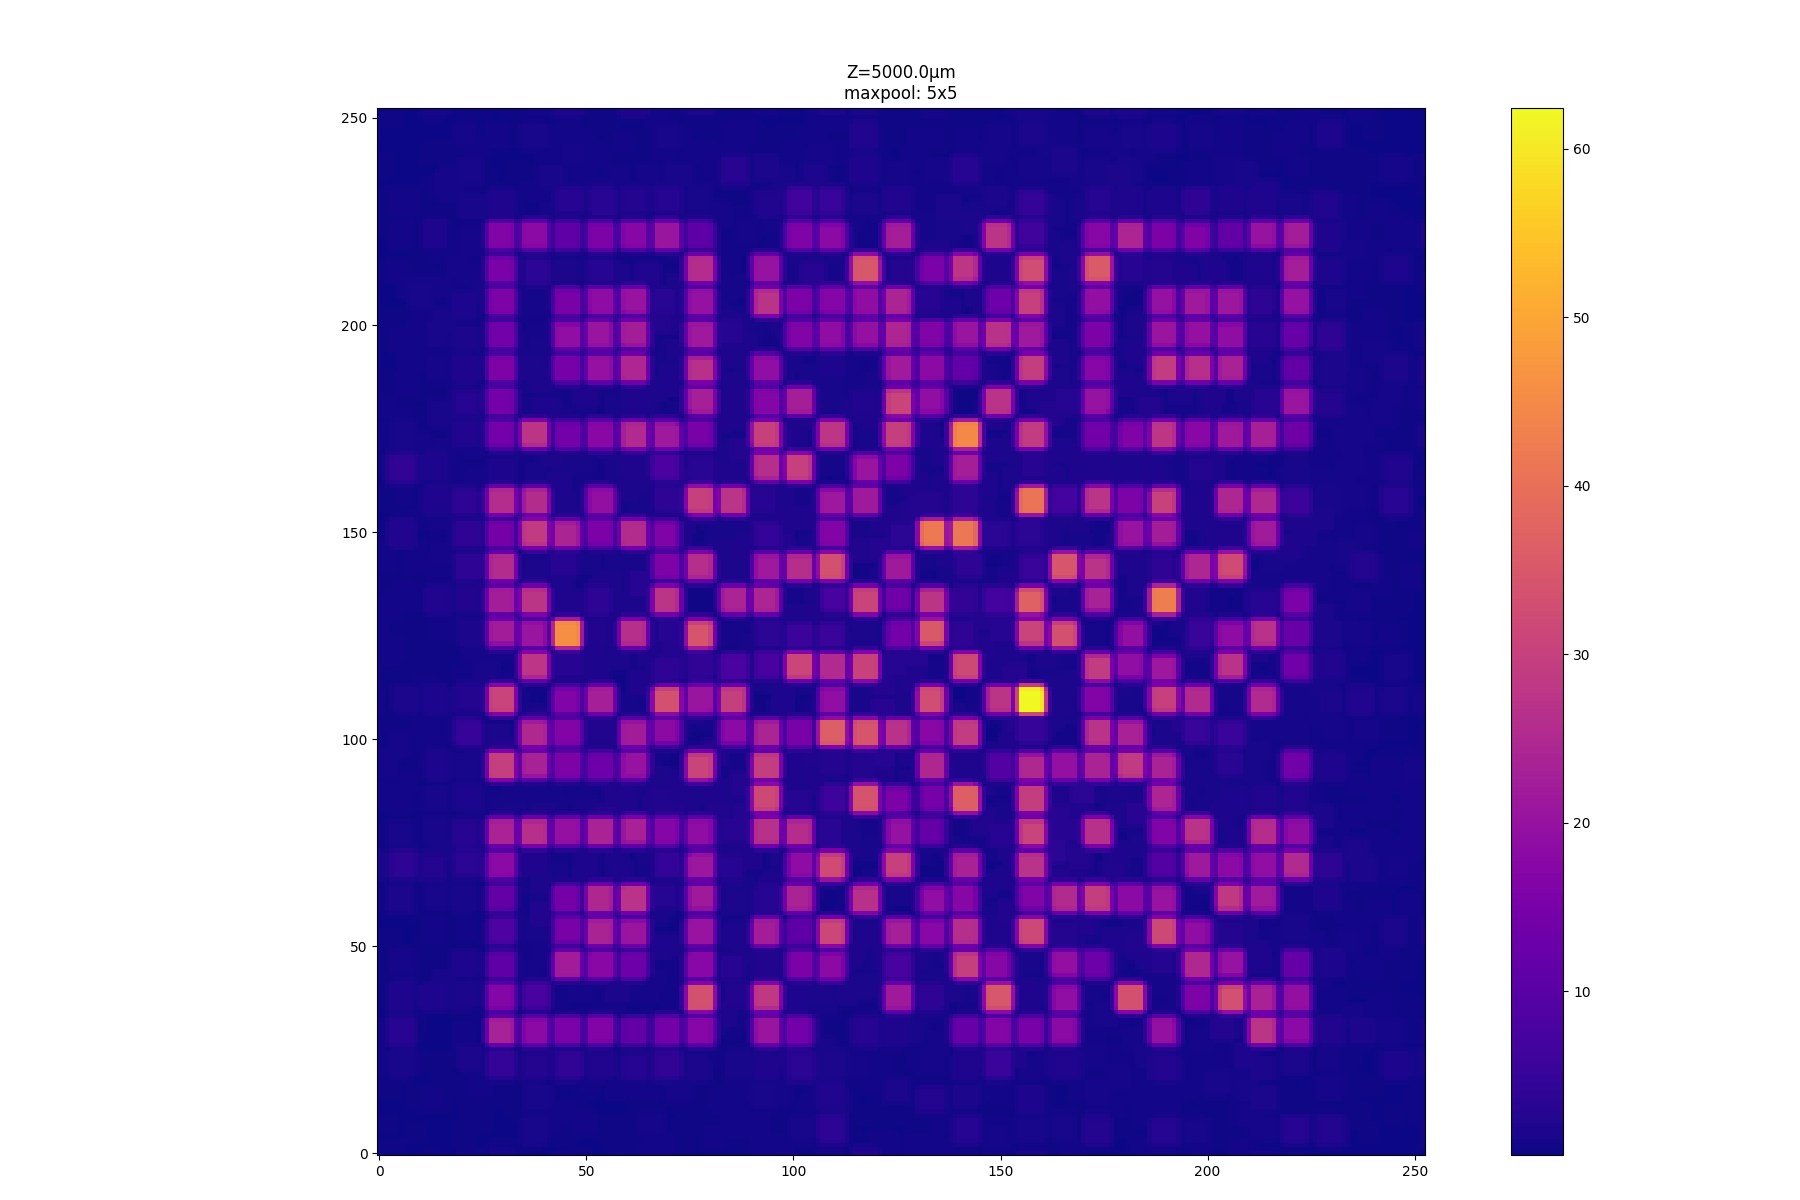

In [5]:
conv = 5
focal = E2[:, :, plot_z_idxs[1]]
thress = np.linspace(0, 10, 40, endpoint=False)
qr_maxpool = it.conv_lambda2D(focal, kernel_shape=(conv, conv), f=lambda x: x.max(axis=(-1,-2)))
qrs = qr_maxpool[None, :, :] > thress[:, None, None] # N_thres, Nx, Ny
plt.clf()
plt.title(f'Z={c.zs[plot_z_idxs[1]]}μm\nmaxpool: {conv}x{conv}')
plt.imshow(qr_maxpool.T, cmap='plasma')
plt.colorbar()
plt.gca().invert_yaxis()
plt.savefig(f'{c.path.results}/focal_maxpool.png', bbox_inches='tight')
plt.show()

In [ ]:
plt.close(fig)
plt.clf()
ani = it.arr_2_mp4(qrs, path=f'{c.path.results}/focal_maxpool_thres.mp4', fps=5, title=lambda thres_idx: f'Z={c.zs[plot_z_idxs[1]]}μm    maxpool: {conv}x{conv}\nintensity thres: {thress[thres_idx]:.2f}')

In [ ]:
it.arr_2_mp4(np.moveaxis(E2, -1, 0), path=f'{c.path.results}/E2.mp4', fps=60, title=lambda z_idx: f'z: {c.zs[z_idx]}μm')

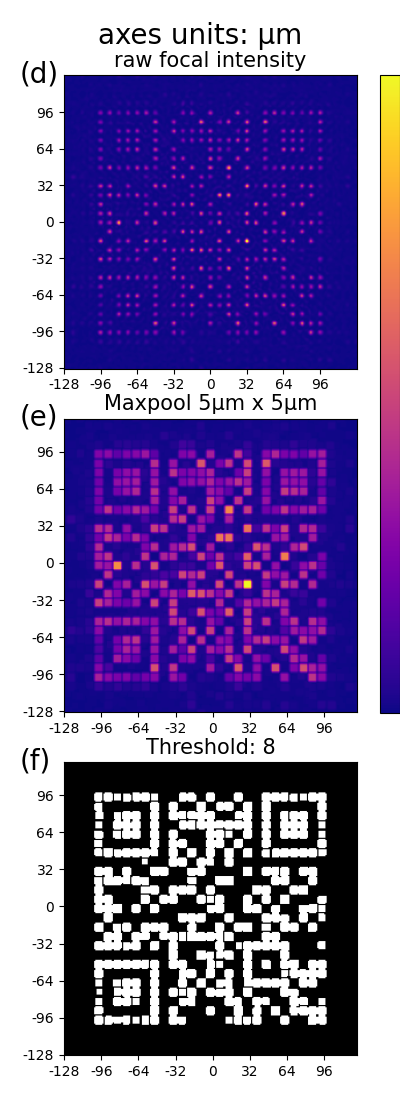

In [6]:
# x, y plot at different zs
thres = 8
focal_z_idx = 500
layout = [[0], [1], [2]]                                                         # <-- edit plotted z-location here
plots = [E2[:, :, plot_z_idxs[1]], qr_maxpool, qr_maxpool > thres]
titles = [f"raw focal intensity", f"Maxpool {conv}μm x {conv}μm", f"Threshold: {thres}"]
labels = ['(d)', '(e)', '(f)']
plt.clf()
fig, ax = plt.subplot_mosaic(layout, figsize=(4,11))
fig.suptitle(f'axes units: μm', fontsize=20)
fig.tight_layout(pad=1.5)
ims = []
for i in range(len(plots)):
    cmap = 'plasma'
    if i==2:
        cmap = 'gray'
    ims.append(ax[i].imshow(plots[i].T, aspect='equal', cmap=cmap))
    ax[i].invert_yaxis()
    ax[i].set_xticks(c.x_tick_idxs, (c.xs[c.x_tick_idxs]).astype(int))
    ax[i].set_yticks(c.y_tick_idxs, (c.ys[c.y_tick_idxs]).astype(int))
    ax[i].set_title(titles[i], fontsize=15)
    ax[i].text(
        -0.15, 1.05,
        labels[i],
        transform=ax[i].transAxes,  # 0–1 in each direction
        ha="left", va="top",
        color="black",
        fontsize=20,
    )
cax = fig.add_axes([0.95, 0.352, 0.05, 0.58])

fig.colorbar(ims[0], cax=cax)

plt.savefig(f'{c.path.results}/report_QR.png', bbox_inches='tight')
plt.show()

In [7]:
rickroll_QR = it.img_2_array('aperture/rickrollQR_f5_zoom_pad2048.bmp')[512:-512, 512:-512]
HKUST_QR = it.img_2_array('aperture/HKUST_QR_f5_1024.bmp')
mask = it.block_edge_mask(1024, 1024, 500)

In [29]:
print(rickroll_QR + (mask == False))

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [ ]:
it.array_2_img(rickroll_QR + (mask == False), 'aperture/rickrollQR_f5.bmp')

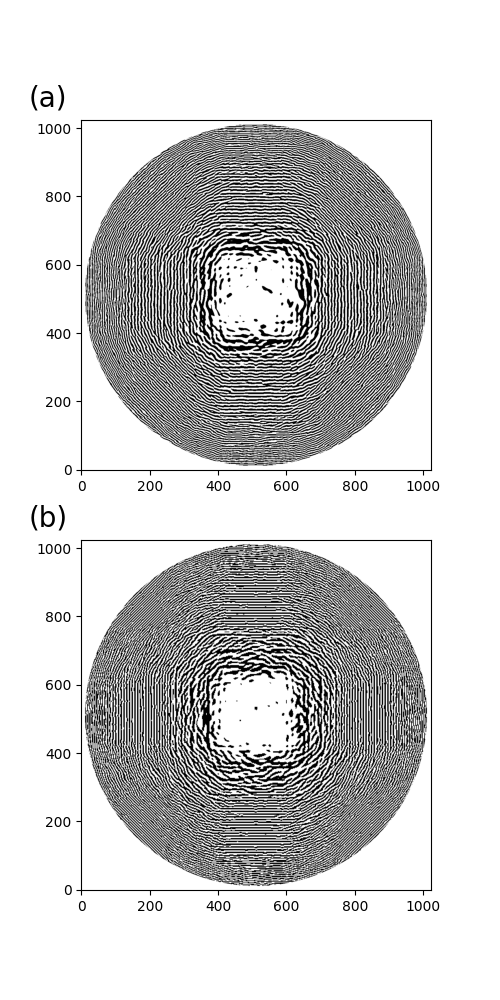

In [40]:
layout = [[0], [1]]

plots = [HKUST_QR, rickroll_QR + (mask == False)]
labels = ['(a)', '(b)']
fig, ax = plt.subplot_mosaic(layout, figsize = (5, 10))
for i in range(len(plots)):
    ax[i].imshow(plots[i].T, aspect='equal', cmap='gray')
    ax[i].invert_yaxis()
    ax[i].text(
        -0.15, 1.1,
        labels[i],
        transform=ax[i].transAxes,  # 0–1 in each direction
        ha="left", va="top",
        color="black",
        fontsize=20,
    )
plt.savefig(f'img/tmp/report_QR_apertures.png', bbox_inches='tight', dpi=200)
plt.show()